# ML2 Assignment #4

**Janin Jankovski, Florian Robrecht, Anna Hartmann**

---

The devised program estimates robustly, given very noisy and very sparse data of infected and recovered of a past epidemic, the basic reproduction number of the SIR model. To keep computation in limit, we assume gamma=1. The SIR model is implemented in a minimal and optimal way, using scaled variables and a scaled time. Only the ODE part is numerically integrated that needs to be integrated. The noisy number of infected and the number of recovered are highly correlated. This relationship helps MCMC infer the parameters.

Get familiar with the commented MCMC code below.

**Task:**
Change the program to the SIRD model, by including (D)eaths, with rate $\mu$. Fix not only $\gamma=1$ but also $\beta=2.5$ (or to a higher value of your choice).
Infer the death rate $\mu$, given noisy $S(t)$, $I(t)$, $R(t)$, $D(t)$ input curves.
If you want, you can try to optimze the code (optional, very very hard).
Also optional is: Does the inference for $\mu$ work, if $S(t)$ and/or $R(t)$ are not given ?
You may use these (initial) conditions/parameters: $$i0 = 0.01,\ s0 = 0.99,\ r0 = 0,\ d0 = 0,\ f = 3.0,\ \text{timestep} = 0.5.$$
You may assume values for the respective $\sigma$'s (log-normal noises) in the range of $0.2-0.4$, but not lower than $0.1$. For assessment use HPD plots, or similar. Good luck and have fun.

---

## The SIRD model

The classical SIR epidemic model has three compartments. We extend it by adding a **death** compartment $D$, so individuals leave $I$ either by recovering (rate $\gamma$) or by dying (rate $\mu$).

| Symbol | Compartment | Meaning |
|---|---|---|
| $S(t)$ | Susceptible | fraction of the population still at risk of infection |
| $I(t)$ | Infected    | fraction currently infectious |
| $R(t)$ | Recovered   | fraction that has recovered (assumed immune) |
| $D(t)$ | Dead        | fraction that has died from the disease |

All four quantities are **scaled fractions** of the total population, so the conservation law

$$ S(t) + I(t) + R(t) + D(t) = 1 $$

holds at every time $t$.

### Differential equations

Following the auxiliary notes (eqs. 11–14), the scaled SIRD ODEs are

$$
\dot s = -\beta\, s\, i, \qquad
\dot i = \beta\, s\, i - (\gamma + \mu)\, i, \qquad
\dot r = \gamma\, i, \qquad
\dot d = \mu\, i.
$$

Each term has a clear meaning: $\beta s i$ is the rate at which susceptibles get infected (proportional to contact between $S$ and $I$), $\gamma i$ is the recovery flow out of $I$, and $\mu i$ is the death flow out of $I$. Because of conservation we can save one ODE: we integrate only $(r, d, i)$ and reconstruct $s = 1 - r - d - i$.

### Basic reproduction number

With the death channel the basic reproduction number becomes

$$ \mathcal{R}_0 = \frac{\beta}{\gamma + \mu}. $$

For the fixed assignment values $\gamma = 1,\ \beta = 2.5$ this gives $\mathcal{R}_0(\mu) = 2.5 / (1 + \mu)$. The ground-truth value $\mu_\text{true} = 0.3$ we use below corresponds to $\mathcal{R}_0 \approx 1.92$ — well above the epidemic threshold, so we get a clear infection peak that MCMC can latch onto.

In [2]:
# macOS / PyTensor compiler workaround — run BEFORE importing pymc.
import os, sys, subprocess
if sys.platform == "darwin":
    try:
        sdk = subprocess.check_output(["xcrun", "--show-sdk-path"], text=True).strip()
        os.environ.setdefault("SDKROOT", sdk)
        import pytensor
        pytensor.config.cxx = "/usr/bin/clang++"
        pytensor.config.gcc__cxxflags = f"-I{sdk}/usr/include/c++/v1"
        print("Configured PyTensor C++ flags for macOS SDK:", pytensor.config.gcc__cxxflags)
    except Exception as exc:
        print("Could not configure PyTensor compiler workaround:", repr(exc))

In [3]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
%precision 4
%matplotlib inline
import pymc as pm
from pymc.ode import DifferentialEquation
from scipy.integrate import odeint
import arviz as az
import warnings
warnings.filterwarnings("ignore")
from warnings import simplefilter
simplefilter(action="ignore", category=FutureWarning)
np.random.seed(42)

import pytensor
print("cxx:", pytensor.config.cxx)

cxx: "C:\Users\Anna\anaconda3\envs\py311\Library\mingw-w64\bin\g++.EXE"


## 1. Initial conditions and the SIRD ODE

We set the assignment defaults — 1% initially infected, the rest susceptible — and define the optimized SIRD ODE that integrates only $(r, d, i)$ (with $s$ reconstructed from the conservation law). $\beta=2.5$ and $\gamma=1$ are fixed as required; the **ground truth** the MCMC sampler will try to recover is $\mu_\text{true} = 0.3$, giving $\mathcal{R}_0 = 2.5 / 1.3 \approx 1.92$ (that is we have cases that infect other cases - an epidemic).


In [15]:
# initial conditions / parameters from the assignment
i0 = 0.01    # 1% infected at t=0
s0 = 0.99    # 99% susceptible at t=0
r0 = 0.00    # 0% recovered at t=0
d0 = 0.00    # 0% dead at t=0   
f  = 3.0     # timestamp will be from t=0 to t=15
timestep_data = 0.5 # e.g. bi-weekly

# fixed model parameters
beta  = 2.5
gamma = 1.0

# ground truth we want MCMC to recover
mu_true = 0.3
print(f"Ground-truth R0 = beta/(gamma+mu) = {beta/(gamma+mu_true):.4f}")

times = np.arange(0.0, 5*f, timestep_data)


def SIRD(y, t, p):
    """Optimized SIRD: integrate (r, d, i); recover s from conservation.
    
    y = [r, d, i, s]
    p = [beta, gamma, mu]
    """
    r, d, i = y[0], y[1], y[2]
    s = 1.0 - r - d - i

    # flow equations
    dr = p[1] * i
    dd = p[2] * i
    di = p[0] * s * i - (p[1] + p[2]) * i
    return [dr, dd, di]


# generate clean curves with scipy.odeint
y_clean = odeint(SIRD, t=times, y0=[r0, d0, i0],
                 args=([beta, gamma, mu_true],), rtol=1e-8)
r_curve, d_curve, i_curve = y_clean.T
s_curve = 1.0 - r_curve - d_curve - i_curve

print("max |s+i+r+d - 1| =",
      np.max(np.abs(s_curve + i_curve + r_curve + d_curve - 1.0)))

Ground-truth R0 = beta/(gamma+mu) = 1.9231
max |s+i+r+d - 1| = 1.1102230246251565e-16


## 2. Generate noisy observations

To imitate "very noisy and very sparse" epidemic data (due to measurement error, underreporting etc.), we change the clean curves with *multiplicative log-normal* noise. Higher values have more spread. 

The assignment allows per-compartment $\sigma \in [0.2, 0.4]$; we use $\sigma = (0.25,\, 0.25,\, 0.30,\, 0.35)$ for $(S, I, R, D)$ — a little more noise on the smaller compartments to make inference challenging. We skip $t=0$ in the observations because $R(0) = D(0) = 0$ and a log-normal sample at zero is degenerate. The constant `eps = 1e-6` inside the log is the numerical safeguard from eq. (21) of the auxiliary notes.

The plot below overlays the clean ground-truth curves (lines) with the noisy observations the sampler will actually see (dots).


yobs shape (T-1, 4): (29, 4)


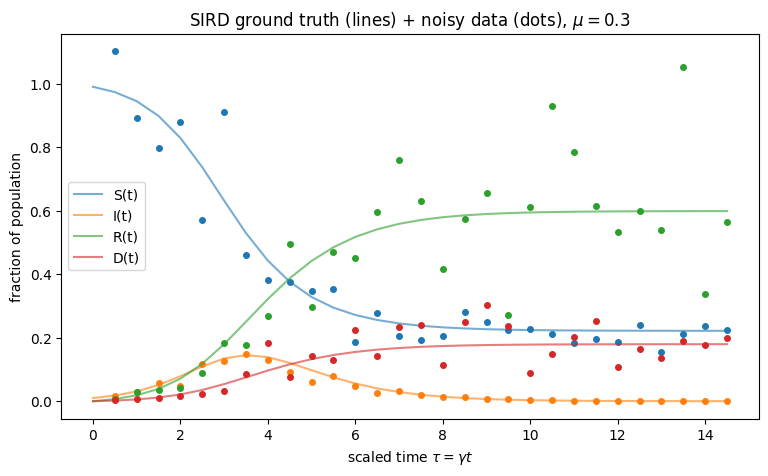

In [5]:
# multiplicative lognormal noise on all four compartments (skip t=0 where r=d=0)
eps = 1e-6  # numerical safeguard inside the log (auxiliary PDF, eq. 21)
sigmas_true = np.array([0.25, 0.25, 0.30, 0.35])  # s, i, r, d

clean_obs = np.column_stack([s_curve, i_curve, r_curve, d_curve])[1:]  # shape (T-1, 4)
yobs = np.random.lognormal(mean=np.log(clean_obs + eps), sigma=sigmas_true)
print("yobs shape (T-1, 4):", yobs.shape)

fig, ax = plt.subplots(figsize=(9, 5))
labels = ["S(t)", "I(t)", "R(t)", "D(t)"]
colors = ["C0", "C1", "C2", "C3"]
for k, (lab, col) in enumerate(zip(labels, colors)):
    ax.plot(times, [s_curve, i_curve, r_curve, d_curve][k],
            color=col, alpha=0.6, label=lab)
    ax.plot(times[1:], yobs[:, k], "o", color=col, markersize=4)
ax.set_xlabel(r"scaled time $\tau = \gamma t$")
ax.set_ylabel("fraction of population")
ax.set_title(f"SIRD ground truth (lines) + noisy data (dots), $\\mu={mu_true}$")
ax.legend()
plt.show()

*Interpretation:* Susceptible $S$ falls as the epidemic spreads, infected $I$ shows the classic single peak around $t \approx 4$, and $R$ and $D$ rise monotonically toward their plateaus — the multiplicative noise visibly scatters the observations around the deterministic curves, especially for the smaller compartments $R$ and $D$.

## 3. PyMC ODE wrapper

PyMC's `DifferentialEquation` needs the same SIRD dynamics expressed for its symbolic backend. The function `SIRD_pymc` is identical in math to `SIRD` from step 1, but now $\beta$ and $\gamma$ are captured as fixed Python constants from the enclosing scope and **only $\mu$ is exposed as a free parameter** (`n_theta = 1`).

The `times=` argument is set to match the time grid of `yobs` (everything *after* $t=0$, where the log-normal noise was well-defined). The integrator returns three states $(r, d, i)$ at those times; the model code in the next step reconstructs $s = 1 - r - d - i$ before evaluating the likelihood.


In [7]:
# Same SIRD as above, written for the PyMC ode container.
def SIRD_pymc(y, t, p):
    # y = [r, d, i]; p = [mu] (beta, gamma are fixed)
    r, d, i = y[0], y[1], y[2]
    s = 1.0 - r - d - i
    dr = gamma * i
    dd = p[0] * i
    di = beta * s * i - (gamma + p[0]) * i
    return [dr, dd, di]


sird_model = DifferentialEquation(
    func=SIRD_pymc,
    times=np.arange(timestep_data, 5*f, timestep_data),  # match yobs times
    n_states=3,    # r, d, i (s is reconstructed)
    n_theta=1,     # only mu is inferred
    t0=0.0,
)

## 4. Run MCMC

**Priors**
- $\mu$: a death rate must be positive, so we use a truncated normal centered at $0.3$ with a wide spread ($\sigma = 0.5$). Wide enough that the data, not the prior, drives the answer. (we check how other priors affect the outcome in section 6)
- $\sigma_c$ (one per compartment): a `HalfCauchy(1.0)` — a positive "I don't know how noisy the data is" prior that allows both small and large noise.

**Likelihood:** the same log-normal noise we used to generate the data in step 2, so the model knows what kind of errors to expect.

**Sampler:** NUTS (PyMC's default), started from the MAP estimate so the chain begins in a good spot. 400 tuning + 400 sampling draws is small but enough for a laptop.



In [8]:
import pytensor.tensor as pt

with pm.Model() as sird_inference:
    # per-compartment lognormal noise scales (s, i, r, d)
    sigma = pm.HalfCauchy("sigma", 1.0, shape=4)

    # death rate prior: strictly positive, broad
    mu = pm.TruncatedNormal("mu", mu=0.3, sigma=0.5, lower=0.01)

    # solve ODE for current mu — returns shape (T-1, 3) for (r, d, i)
    rdi_curves = sird_model(y0=[r0, d0, i0], theta=[mu])

    r_t = rdi_curves[:, 0]
    d_t = rdi_curves[:, 1]
    i_t = rdi_curves[:, 2]
    s_t = 1.0 - r_t - d_t - i_t  # reconstruct susceptible curve

    # stack into (T-1, 4) to match yobs columns (s, i, r, d)
    sird_curves = pt.stack([s_t, i_t, r_t, d_t], axis=1)

    # derived quantity: track R0(mu) explicitly
    R0 = pm.Deterministic("R0", beta / (gamma + mu))

    # lognormal likelihood — eps inside the log for numerical safety
    Y = pm.Lognormal("Y",
                     mu=pm.math.log(sird_curves + eps),
                     sigma=sigma,
                     observed=yobs)

    start = pm.find_MAP()
    step = pm.NUTS()
    trace = pm.sample(400, tune=400, step=step, cores=1,
                       random_seed=44, initvals=start)

Output()

Sequential sampling (2 chains in 1 job)
NUTS: [sigma, mu]


Output()

Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 539 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


### 5. Diagnostics and posterior

1. **Trace plot + summary**
2. **Pair plot for $(\mu, \sigma)$**
3. **Posterior predictive curves** 

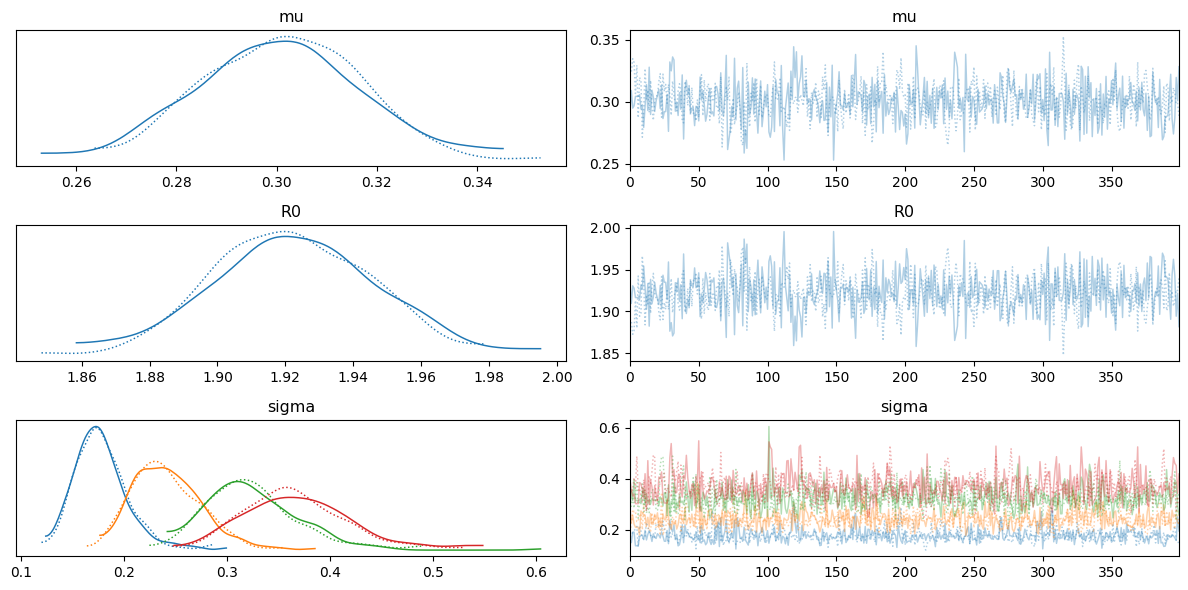

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,0.301,0.016,0.271,0.329,0.001,0.000,745.0,557.0,1.0
R0,1.922,0.023,1.881,1.966,0.001,0.001,745.0,557.0,1.0
sigma[0],0.178,0.026,0.133,0.224,0.001,0.001,692.0,563.0,1.0
sigma[1],0.242,0.033,0.185,0.303,0.001,0.001,769.0,662.0,1.0
sigma[2],0.325,0.045,0.242,0.401,0.001,0.002,959.0,705.0,1.0
sigma[3],0.368,0.052,0.278,0.471,0.002,0.002,685.0,602.0,1.0


In [9]:
# Trace plot
az.plot_trace(trace, var_names=["mu", "R0", "sigma"])
plt.tight_layout()
plt.show()
pm.summary(trace, var_names=["mu", "R0", "sigma"]).round(3)

*Interpretation:* The traces look like white noise (no drift, no stuck regions) and the marginal posterior for $\mu$ is tightly concentrated around the true value $0.3$ (giving $\mathcal{R}_0 \approx 1.92$) — the sampler has converged and recovered the ground-truth death rate. All chains convered with r_hat = 1.0 and ess_bulk shows effective samples over 700+.

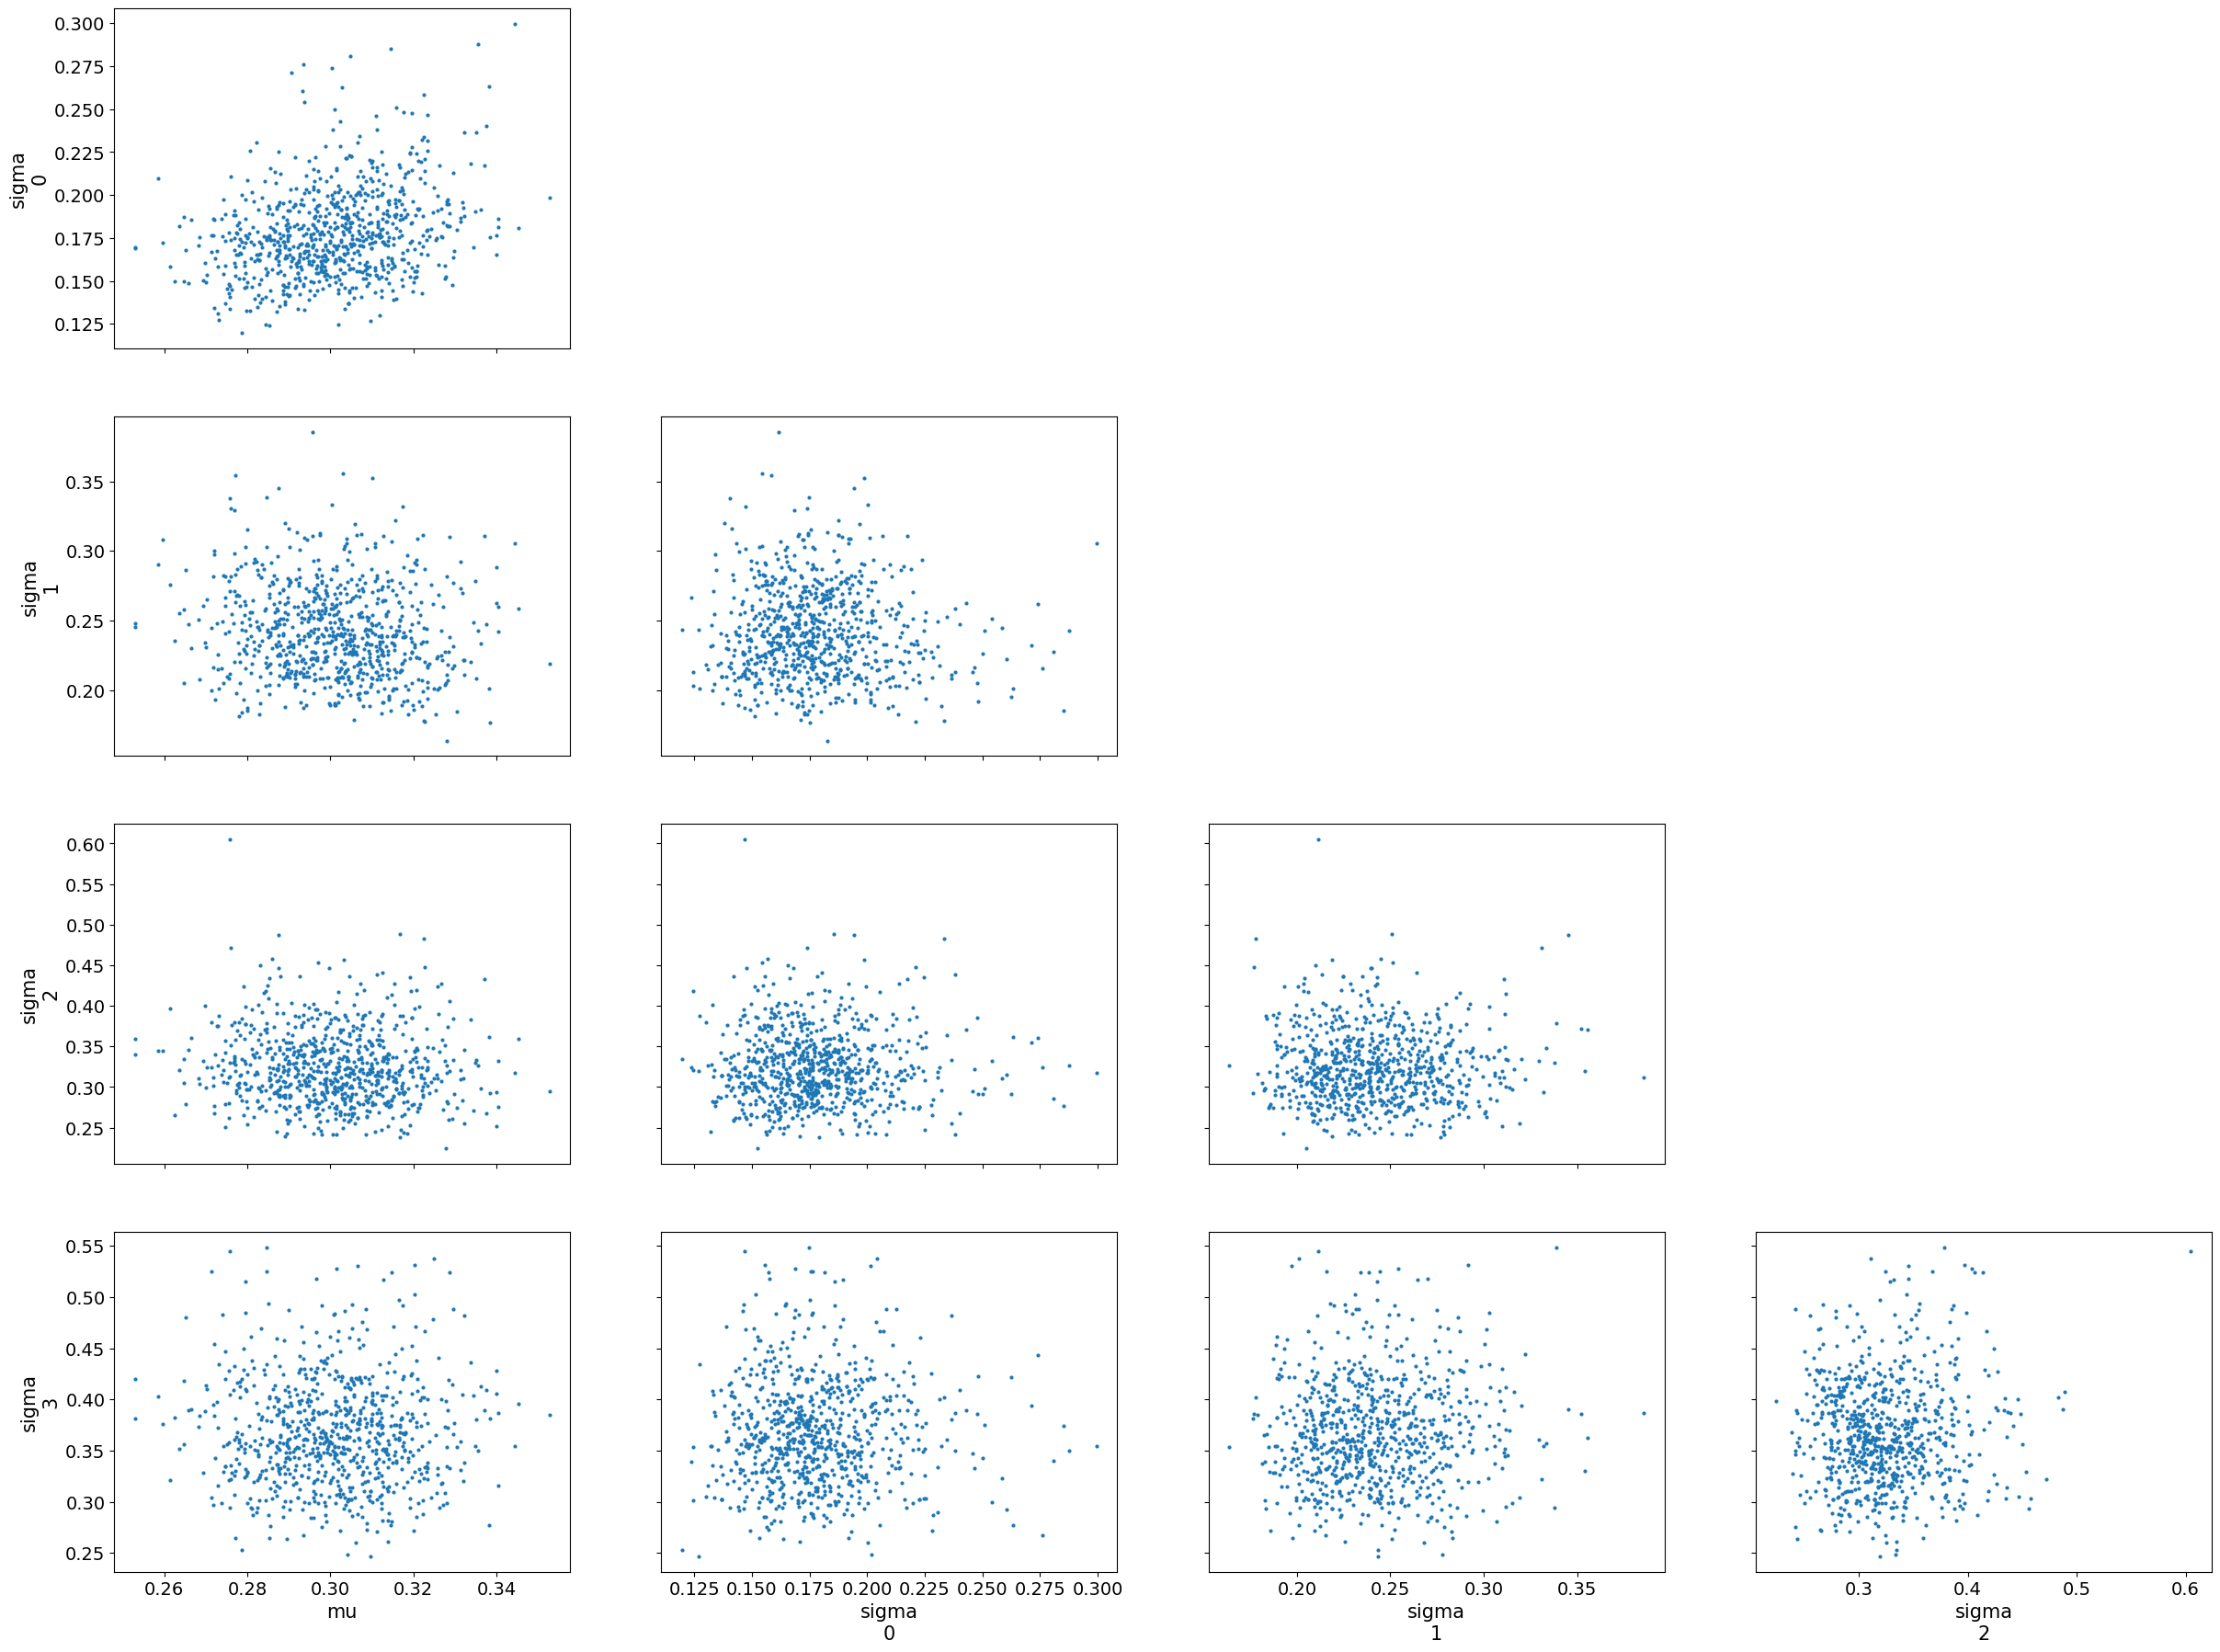

In [10]:
# Pair plot
az.plot_pair(trace, var_names=["mu", "sigma"], divergences=True)
plt.show()

*Interpretation:* The $(\mu, \sigma_c)$ scatter clouds are roughly spherical with no visible correlations and no divergent transitions (which would appear as red points).

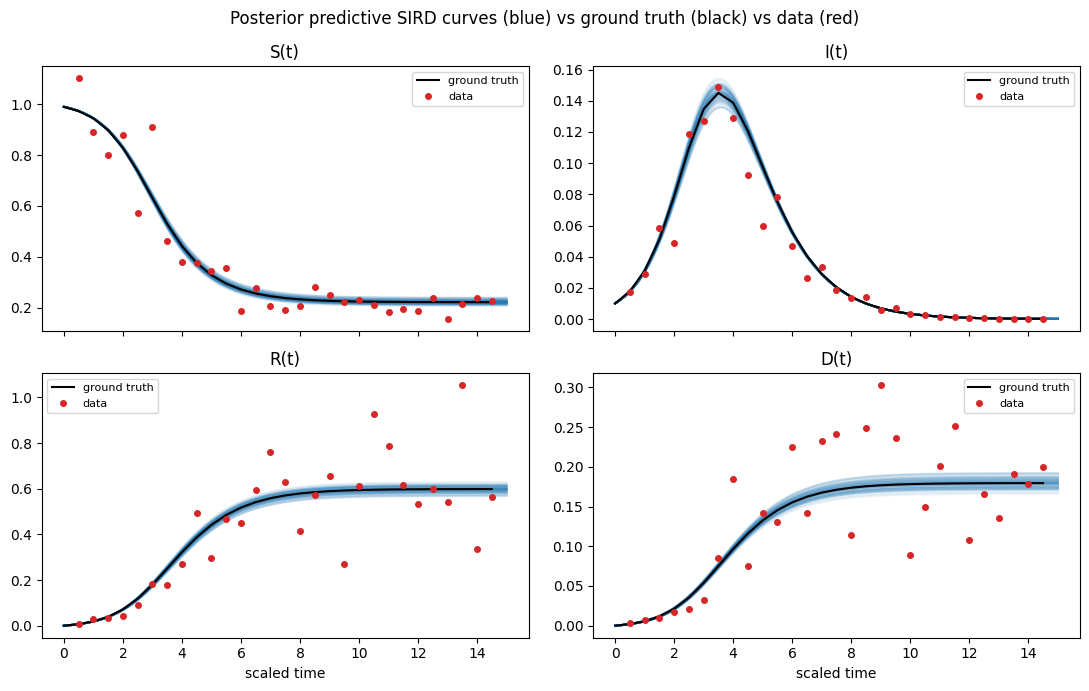

In [11]:
# Posterior predictive curves
post_mu = trace.posterior["mu"].values.flatten()
n_draws = 80 # samples
draws = np.random.choice(post_mu, size=n_draws, replace=False)

fine_times = np.linspace(0, 5*f, 200)
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
labels = ["S(t)", "I(t)", "R(t)", "D(t)"]

for mu_draw in draws:
    y = odeint(SIRD, t=fine_times, y0=[r0, d0, i0],
               args=([beta, gamma, mu_draw],), rtol=1e-8)
    r_, d_, i_ = y.T
    s_ = 1.0 - r_ - d_ - i_
    curves = [s_, i_, r_, d_]
    for ax, c in zip(axes.flat, curves):
        ax.plot(fine_times, c, color="C0", alpha=0.08)

for ax, lab, obs_col, gt in zip(axes.flat, labels, yobs.T,
                                [s_curve, i_curve, r_curve, d_curve]):
    ax.plot(times, gt, color="k", lw=1.5, label="ground truth")
    ax.plot(times[1:], obs_col, "o", color="C3", markersize=4, label="data")
    ax.set_title(lab)
    ax.legend(fontsize=8)
axes[1,0].set_xlabel("scaled time")
axes[1,1].set_xlabel("scaled time")
plt.suptitle("Posterior predictive SIRD curves (blue) vs ground truth (black) vs data (red)")
plt.tight_layout()
plt.show()

*Interpretation:* For all four compartments the blue posterior-predictive cloud hugs the black ground-truth curves and passes through the red noisy observations, confirming that the inferred $\mu$ reproduces the full epidemic trajectory — not just the marginal mean. Uncertainty is highest where the spread of the data is widest. 

## 6. Prior sensitivity for $\mu$

The baseline inference uses `TruncatedNormal(mu=0.3, sigma=0.5, lower=0.01)`, which happens to be centered on the true value. To check that the data — not the prior — is driving the posterior, we re-run inference with three priors of varying location *and* width:

- **low**: `mu=0.10, sigma=0.20` — narrow, centered well below the truth (0.3).
- **centered**: `mu=0.30, sigma=0.50` — broad, matches the baseline.
- **high**: `mu=0.60, sigma=0.20` — narrow, centered well above the truth.

If the likelihood is informative enough, all three posteriors should concentrate near $\mu_{\text{true}}=0.3$ regardless of where the prior was centered. A posterior that stays pinned to its prior would indicate weak identifiability.

running: low (mu=0.10, sigma=0.20)


Output()

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [sigma, mu]
Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 269 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


running: centered (mu=0.30, sigma=0.50)


Output()

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [sigma, mu]
Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 239 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


running: high (mu=0.60, sigma=0.20)


Output()

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [sigma, mu]
Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 233 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


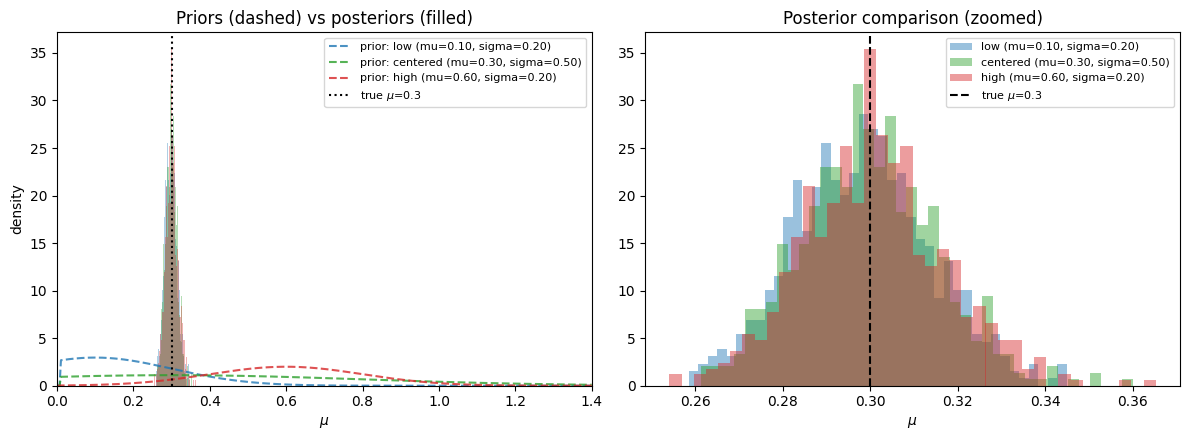

94% HDI for mu under each prior:
            low (mu=0.10, sigma=0.20): mean=0.298  HDI=[0.270, 0.328]  width=0.058
       centered (mu=0.30, sigma=0.50): mean=0.300  HDI=[0.272, 0.328]  width=0.056
           high (mu=0.60, sigma=0.20): mean=0.301  HDI=[0.272, 0.333]  width=0.061


In [ ]:
from scipy import stats

# (label, prior_mu, prior_sigma) — true mu is 0.3
prior_configs = [
    ("low (mu=0.10, sigma=0.20)",      0.10, 0.20),
    ("centered (mu=0.30, sigma=0.50)", 0.30, 0.50),  # = baseline
    ("high (mu=0.60, sigma=0.20)",     0.60, 0.20),
]


def run_mu_prior(prior_mu, prior_sigma, draws=300, tune=300, seed=44):
    with pm.Model() as m:
        sigma = pm.HalfCauchy("sigma", 1.0, shape=4)
        mu_ = pm.TruncatedNormal("mu", mu=prior_mu, sigma=prior_sigma, lower=0.01)

        rdi = sird_model(y0=[r0, d0, i0], theta=[mu_])
        r_t, d_t, i_t = rdi[:, 0], rdi[:, 1], rdi[:, 2]
        s_t = 1.0 - r_t - d_t - i_t
        curves = pt.stack([s_t, i_t, r_t, d_t], axis=1)

        pm.Deterministic("R0", beta / (gamma + mu_))
        pm.Lognormal("Y", mu=pm.math.log(curves + eps),
                     sigma=sigma, observed=yobs)

        start = pm.find_MAP()
        tr = pm.sample(draws, tune=tune, cores=1, random_seed=seed,
                       initvals=start, progressbar=False)
    return tr


prior_traces = {}
for label, pm_, ps_ in prior_configs:
    print(f"running: {label}")
    prior_traces[label] = run_mu_prior(pm_, ps_)

# comparison plot: priors (dashed) vs posteriors (filled)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
mu_grid = np.linspace(0.0, 1.4, 400)
colors = ["C0", "C2", "C3"]

for (label, pm_val, ps_val), c in zip(prior_configs, colors):
    a = (0.01 - pm_val) / ps_val
    prior_pdf = stats.truncnorm.pdf(mu_grid, a=a, b=np.inf, loc=pm_val, scale=ps_val)
    axes[0].plot(mu_grid, prior_pdf, color=c, ls="--", alpha=0.8,
                 label=f"prior: {label}")
    post = prior_traces[label].posterior["mu"].values.flatten()
    axes[0].hist(post, bins=40, density=True, alpha=0.35, color=c)
axes[0].axvline(mu_true, color="k", lw=1.5, ls=":", label=f"true $\\mu$={mu_true}")
axes[0].set_xlabel(r"$\mu$")
axes[0].set_ylabel("density")
axes[0].set_title("Priors (dashed) vs posteriors (filled)")
axes[0].legend(fontsize=8)
axes[0].set_xlim(0, 1.4)

for (label, *_), c in zip(prior_configs, colors):
    post = prior_traces[label].posterior["mu"].values.flatten()
    axes[1].hist(post, bins=40, density=True, alpha=0.45, color=c, label=label)
axes[1].axvline(mu_true, color="k", lw=1.5, ls="--", label=f"true $\\mu$={mu_true}")
axes[1].set_xlabel(r"$\mu$")
axes[1].set_title("Posterior comparison (zoomed)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print("94% HDI for mu under each prior:")
for label, tr in prior_traces.items():
    hdi = az.hdi(tr, var_names=["mu"], hdi_prob=0.94)["mu"].values
    mean = float(tr.posterior["mu"].mean())
    print(f"  {label:>35s}: mean={mean:.3f}  HDI=[{hdi[0]:.3f}, {hdi[1]:.3f}]  width={hdi[1]-hdi[0]:.3f}")

*Interpretation:* Even though the three priors (dashed) are centered very differently (at $0.1$, $0.3$, and $0.6$) and two of them are narrow, the three posteriors (filled) collapse onto essentially the **same** distribution peaked at $\mu \approx 0.30$ with nearly identical 94% HDIs (widths $\approx 0.06$). The likelihood overwhelms the prior, so the result is driven by the data — not by where we placed the prior.

## 7. Optional experiment: Is $\mu$ identifiable from incomplete data?

The assignment asks whether the death rate can still be inferred if some of the four curves are missing. We re-run inference observing only a subset of $\{S, I, R, D\}$ and compare the resulting posteriors for $\mu$.

Intuitively:

- **Removing $D(t)$ should hurt the most**, because $D$ is the only compartment that *directly* carries information about $\mu$ — its ODE is $\dot D = \mu I$, so observing $D$ pins down $\mu$ almost on its own.
- **Removing $S$ or $R$ should hurt less** — both are still coupled to $\mu$ indirectly through the dynamics of $I$, and the conservation law $S+I+R+D=1$ lets the remaining curves partially reconstruct the missing one.

We quantify "how hurt" by comparing the **94% HDI width** for $\mu$ across regimes: a wider HDI means a less identifiable posterior.


In [13]:
def run_sird_inference(observed_idx, name, draws=300, tune=300, seed=44):
    """Run SIRD MCMC observing only compartments listed in observed_idx.

    observed_idx is a subset of (0, 1, 2, 3) for (s, i, r, d).
    """
    yobs_sub = yobs[:, observed_idx]
    n_obs = len(observed_idx)

    with pm.Model() as m:
        sigma = pm.HalfCauchy("sigma", 1.0, shape=n_obs)
        mu_ = pm.TruncatedNormal("mu", mu=0.3, sigma=0.5, lower=0.01)

        rdi = sird_model(y0=[r0, d0, i0], theta=[mu_])
        r_t, d_t, i_t = rdi[:, 0], rdi[:, 1], rdi[:, 2]
        s_t = 1.0 - r_t - d_t - i_t
        all_curves = pt.stack([s_t, i_t, r_t, d_t], axis=1)
        sub_curves = all_curves[:, observed_idx]

        pm.Deterministic("R0", beta / (gamma + mu_))
        pm.Lognormal("Y", mu=pm.math.log(sub_curves + eps),
                     sigma=sigma, observed=yobs_sub)

        start = pm.find_MAP()
        tr = pm.sample(draws, tune=tune, cores=1, random_seed=seed,
                       initvals=start, progressbar=False)
    print(f"[{name}] mu posterior:",
          pm.summary(tr, var_names=["mu"]).round(3))
    return tr


traces = {
    "all (S,I,R,D)": trace,                    # reuse baseline
    "no S":  run_sird_inference([1, 2, 3], "no S"),
    "no R":  run_sird_inference([0, 1, 3], "no R"),
    "no D":  run_sird_inference([0, 1, 2], "no D"),
}

Output()

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [sigma, mu]
Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 214 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


[no S] mu posterior:      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
mu  0.349  0.026   0.298    0.395      0.001    0.001     574.0     439.0   

    r_hat  
mu    1.0  


Output()

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [sigma, mu]
Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 299 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


[no R] mu posterior:      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
mu  0.294  0.016   0.265    0.324      0.001    0.001     567.0     265.0   

    r_hat  
mu    1.0  


Output()

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [sigma, mu]
Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 262 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


[no D] mu posterior:      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
mu  0.296  0.017   0.265    0.332      0.001    0.001     594.0     373.0   

    r_hat  
mu    1.0  


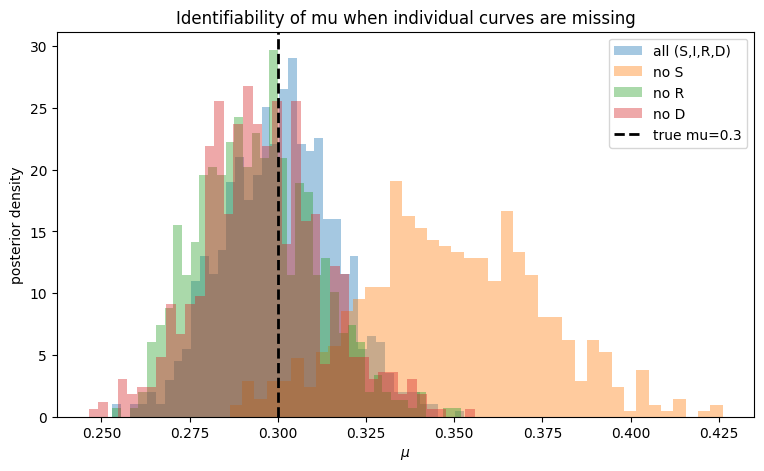

94% HDI width for mu under each observation regime:
    all (S,I,R,D): [0.271, 0.329]  width = 0.057
             no S: [0.298, 0.395]  width = 0.096
             no R: [0.265, 0.324]  width = 0.059
             no D: [0.265, 0.332]  width = 0.066


In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, tr in traces.items():
    samples = tr.posterior["mu"].values.flatten()
    ax.hist(samples, bins=40, density=True, alpha=0.4, label=name)
ax.axvline(mu_true, color="k", lw=2, linestyle="--", label=f"true mu={mu_true}")
ax.set_xlabel(r"$\mu$")
ax.set_ylabel("posterior density")
ax.set_title("Identifiability of mu when individual curves are missing")
ax.legend()
plt.show()

# numerical summary: HDI width is the cleanest scalar measure of identifiability
print("94% HDI width for mu under each observation regime:")
for name, tr in traces.items():
    hdi = az.hdi(tr, var_names=["mu"], hdi_prob=0.94)["mu"].values
    print(f"  {name:>15s}: [{hdi[0]:.3f}, {hdi[1]:.3f}]  width = {hdi[1]-hdi[0]:.3f}")

*Interpretation:* Removing $R$ or $D$ barely changes the posterior — all three curves stay tightly centered on the true $\mu = 0.3$ with HDI widths $\approx 0.06$, basically identical to the full-data baseline. Removing $S$ is a different story: the posterior **shifts to the right** (mode near $0.35$) and the HDI **nearly doubles** in width ($0.096$ vs $0.057$).

The intuition is that $S(t)$ is the pool of people who could **still get infected** — and therefore also the pool that deaths can ultimately be drawn from. Its trajectory tells the sampler the *total reach* of the epidemic ($1 - s(\infty)$, i.e. how many people the disease actually hits). Once we know how many got infected, the recovered-vs-dead split directly fixes the death rate $\mu$. Take $S$ away and we have to infer that total reach from the noisy $R$ and $D$ curves alone — which is a much weaker signal, especially because $R$ and $D$ start at zero and carry the most noise — so $\mu$ becomes harder to pin down and the posterior drifts upward.

## 8. Take-home message

**Initial question:** Can MCMC recover the death rate $\mu$ of a SIRD epidemic from very noisy data?

**Answer: yes — and three things stand out.**

1. **MCMC recovers the truth with tight uncertainty.** The 94% HDI for $\mu$ is roughly $[0.27, 0.33]$ around the true value $0.3$ (so $\mathcal{R}_0 \approx 1.92$), even though every compartment is hit with $20$–$35\%$ multiplicative log-normal noise. The posterior-predictive curves match the ground truth across all four compartments.

2. **The result is driven by the data, not by the prior.** Three very different priors for $\mu$ — narrow-low, broad-centered, narrow-high — collapse to essentially the same posterior with nearly identical HDIs. The likelihood overwhelms the prior, which is the desired behaviour and a strong sanity check.

3. **$\mu$ stays identifiable when curves go missing — but $S(t)$ matters most.** Dropping $R$ or $D$ barely changes the posterior (HDI widths $\approx 0.06$). Dropping $S$ almost doubles the HDI ($0.096$) and shifts the mode upward — the susceptible curve carries more information about the death rate than either $R$ or $D$ on their own.